In [177]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates


In [178]:
# Ticker
symbols = ["BTC"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-06-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 24)

# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3
adx_threshold = 30
ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
# init_cash = 1000

#
k = KrakenHistoricalData()
s = Signals()

df_multi = k.get_ohlcv_df(symbols, interval=interval)
print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                                    BTC                              \
                                   open          high           low   
2023-01-01 00:00:00+00:00  16528.699219  16530.000000  16505.199219   
2023-01-01 04:00:00+00:00  16519.300781  16542.400391  16506.900391   
2023-01-01 08:00:00+00:00  16512.400391  16538.400391  16490.000000   
2023-01-01 12:00:00+00:00  16500.199219  16550.000000  16497.699219   
2023-01-01 16:00:00+00:00  16550.000000  16573.099609  16531.199219   

                                                                         
                                  close        volume trades base quote  
2023-01-01 00:00:00+00:00  16519.300781  2.636628e+10    803  BTC   USD  
2023-01-01 04:00:00+00:00  16510.699219  1.122105e+11   2919  BTC   USD  
2023-01-01 08:00:00+00:00  16500.199219  1.014384e+11   2536  BTC   USD  
2023-01-01 12:00:00+00:00  16549.900391  2.684441e+10   2002  BTC   USD  
2023-01-01 16:00:00+00:00  16553.699219  3.952236e+10   24

In [179]:
# Signals
signals = df.copy()
# moving average
# ma = pta.ohlc4(df['open'],df['high'],df['low'],df['close'])
ma = pta.zlma(df['close'], 10)

# Calculate technical indicators
signals['rsi'] = pta.rsi(df['close'])

# adx > 25 strong trend
adx = pta.adx(df['high'], df['low'], df['close'])

# Entry: SAR Signal
psar = pta.psar(df['high'],
                df['low'],
                close=df['close'])
print(f"\nSAR:")

signals['sar'] = psar.iloc[:, 0]
# signals['sar_s'] = np.where(signals['sar'] > 0, True, False)

signals['sar_s'] = signals['close'] > signals['sar']

print(signals[['sar', 'sar_s']].tail())  # Entry Signals

print(f"\nADX:")
print(tabulate(adx.tail(), headers="keys", tablefmt="github"))
signals['adx'] = adx.iloc[:, 0]
signals['adx_d'] = adx.iloc[:, 1]
signals['adx_dmp'] = adx.iloc[:, 2]
signals['adx_dmn'] = adx.iloc[:, 3]
signals['adx_s'] = np.where(signals['adx'] > adx_threshold, True, False)
signals['adx_bullish'] = np.where(signals['adx_dmp'] > signals['adx_dmn'], True, False)
signals['adx_s'] = signals['adx_s'] & signals['adx_bullish']

# Exit: Chandlier Exit uses ATR
signals['atr'] = pta.atr(df['high'], df['low'], df['close'])
ce = pta.chandelier_exit(df['high'],
                         df['low'],
                         df['close'],
                         multiplier=atr_multiplier, high_length=ce_high_length)
print(f"\nChandlier_Raw")
print(tabulate(ce.tail(), headers="keys", tablefmt="github"))
signals['ce_l'] = np.where(ce.iloc[:, 2] > 0, ce.iloc[:, 0], np.nan)
signals['ce_sh'] = np.where(ce.iloc[:, 2] < 0, ce.iloc[:, 1], np.nan)
signals['ce_exit'] = np.where(ce.iloc[:, 2] == 1, False, True)
print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].tail(50))

# entry

# Have ADX strength, and sar is a buy and ce is not an exit
entry_series = signals['adx_s'] & signals['sar_s'] & ~signals['ce_exit']
entry_rise = entry_series & (~entry_series.shift(1, fill_value=False))

# eixt
exit_series = signals['ce_exit']

exit_rise = exit_series & (~exit_series.shift(1, fill_value=False))

entry_exit_df = pd.concat([entry_series, entry_rise, exit_series, exit_rise], axis=1)
entry_exit_df.columns = ['entry_series', 'entry_rise', 'exit_series', 'exit_rise']

print(f"\nEntry/Exit Signals:")
print(entry_exit_df.tail(50))



SAR:
                                     sar  sar_s
2025-06-29 08:00:00+00:00  106477.203125   True
2025-06-29 12:00:00+00:00  106516.707031   True
2025-06-29 16:00:00+00:00  106594.466875   True
2025-06-29 20:00:00+00:00  106669.116325   True
2025-06-30 00:00:00+00:00  106740.779797   True

ADX:
|                           |   ADX_14 |   ADXR_14_2 |   DMP_14 |   DMN_14 |
|---------------------------|----------|-------------|----------|----------|
| 2025-06-29 08:00:00+00:00 |  16.5153 |     15.9498 |  2608.55 |  1239.24 |
| 2025-06-29 12:00:00+00:00 |  17.8882 |     16.4682 |  2430.53 |  1150.73 |
| 2025-06-29 16:00:00+00:00 |  18.3559 |     17.4356 |  2256.92 |  1370.53 |
| 2025-06-29 20:00:00+00:00 |  19.6316 |     18.7599 |  2717.82 |  1272.64 |
| 2025-06-30 00:00:00+00:00 |  21.2165 |     19.7862 |  2880.58 |  1181.73 |

Chandlier_Raw
|                           |   CHDLREXTl_22_22_14_3 |   CHDLREXTs_22_22_14_3 |   CHDLREXTd_22_22_14_3 |
|---------------------------|------------

In [180]:
# filter entries and exits, one for one entry/exit

in_pos = False
filtered_entry = pd.Series(False, index=signals.index)
filtered_exit = pd.Series(False, index=signals.index)

for ts in signals.index:
    if not in_pos and entry_rise.loc[ts]:
        filtered_entry.loc[ts] = True
        in_pos = True
    elif in_pos and exit_rise.loc[ts]:
        filtered_exit.loc[ts] = True
        in_pos = False
    # elif in_pos and exit_series.loc[ts]:
    #     filtered_exit.loc[ts] = True
    #     in_pos = False
# filtered_exit = filtered_entry.shift(-1, fill_value=False)
i_start = 30 * 6
i_end = 60 * 6
entry_concat = pd.concat([entry_series.iloc[i_start:i_end], filtered_entry.iloc[i_start:i_end]], axis=1)
exit_concat = pd.concat([exit_series.iloc[i_start:i_end], filtered_exit.iloc[i_start:i_end]], axis=1)

print(f"\nFiltered Entry/Exit Signals:")
print(tabulate(pd.concat([entry_concat, exit_concat, signals['ce_l']], axis=1).iloc[i_start:i_end],
               headers=["entry", "filtered_entry", "exit", "filtered_exit", "ce_l"], tablefmt="github"))

print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].iloc[i_start:i_end])

print(f"\nExit Prices:")
print(signals['ce_l'].loc[filtered_exit.shift(-1, fill_value=False).values])


Filtered Entry/Exit Signals:
|                           | entry   | filtered_entry   | exit   | filtered_exit   |    ce_l |
|---------------------------|---------|------------------|--------|-----------------|---------|
| 2023-08-10 00:00:00+00:00 | False   | False            | False  | False           | 29453.6 |
| 2023-08-10 04:00:00+00:00 | False   | False            | False  | False           | 29480.4 |
| 2023-08-10 08:00:00+00:00 | False   | False            | False  | False           | 29512.2 |
| 2023-08-10 12:00:00+00:00 | False   | False            | False  | False           | 29529.5 |
| 2023-08-10 16:00:00+00:00 | False   | False            | False  | False           | 29506.9 |
| 2023-08-10 20:00:00+00:00 | False   | False            | False  | False           | 29528.9 |
| 2023-08-11 00:00:00+00:00 | False   | False            | False  | False           | 29568.7 |
| 2023-08-11 04:00:00+00:00 | False   | False            | False  | False           | 29589.5 |
| 2023-08-

In [181]:
entry_times = list(filtered_entry[filtered_entry].index)
exit_times = list(filtered_exit[filtered_exit].index)

# 2) Pair entries with the next exit after each entry
pairs = []
j = 0
for et in entry_times:
    while j < len(exit_times) and exit_times[j] <= et:
        j += 1
    if j < len(exit_times):
        pairs.append((et, exit_times[j]))
        j += 1

close = signals['close']
exits_price = signals['ce_l'].shift(-1).ffill() * filtered_exit

entries_price = close * filtered_entry
profit = pd.Series(0.0, index=filtered_entry.index)
profit_pct = profit.copy()
for pair in pairs:
    exit_price = exits_price.loc[pair[1]]
    entry_price = entries_price.loc[pair[0]]
    profit.loc[pair[1]] = exit_price - entry_price - (transaction_fee * (exit_price + entry_price))
    profit_pct.loc[pair[1]] = profit.loc[pair[1]] / entry_price

profit_cum = profit.cumsum()
profit[profit == 0.0] = np.nan
profit_pct[profit_pct == 0.0] = np.nan
profit_df = pd.concat([entries_price, exits_price, profit, profit_cum, profit_pct], axis=1)
profit_df.columns = ['Entry_Price', 'Exit_Price', 'Profit', 'Cumulative_Profit', 'Profit_Pct']
wins = (profit_df['Profit'] > 0).sum()
loss = (profit_df['Profit'] < 0).sum()

trading_days = (end - start).days

stats = profit_df['Profit'].describe()
stats_pct = profit_df['Profit_Pct'].describe()
sharpe = stats['mean'] / stats['std'] * np.sqrt(trading_days)

print(f"\nPerformance  Stats:")
print(f"Trading Days: {trading_days}")
print(f"Average Return: {stats['mean']:,.2f}")
print(f"Std.Dev Return: {stats['std']:,.2f}")
print(f"Average Return %: {stats_pct['mean'] * 100:,.2f}")
print(f"Std.Dev Return %: {stats_pct['std'] * 100:,.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Total Profit: {profit_df['Cumulative_Profit'].iloc[-1]:,.2f}")
print(f"Wins: {wins}")
print(f"Losses: {loss}")
print(f"Win Rate: {wins / (wins + loss):.2%}")

# print(f"\nLast 200 profit_df:")
# print(tabulate(profit_df.tail(200), headers='keys',
#                tablefmt='github'))
# With DMP >DMN  sharpe Ratio 6.29, 2 years, BTC
# without DMP> DMN Sharpe Ratio 5.41, 2 years, BTC
# with DMP > DMN Sharpe Ratio 2.08, .5 years, BTC
# without DMP> DMN Sharpe Ratio .29, .5 years, BTC


Performance  Stats:
Trading Days: 720
Average Return: 717.93
Std.Dev Return: 4,137.68
Average Return %: 1.62
Std.Dev Return %: 6.79
Sharpe Ratio: 4.66
Total Profit: 27,999.27
Wins: 19
Losses: 20
Win Rate: 48.72%


In [182]:
##  Boolean where in position
y1_arr = signals['close'].values
in_position = pd.Series(pd.NA, index=filtered_entry.index, dtype="boolean")
in_position[filtered_entry] = filtered_entry[filtered_entry]
in_position[filtered_exit] = ~filtered_exit[filtered_exit]
in_position.ffill(inplace=True)
y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

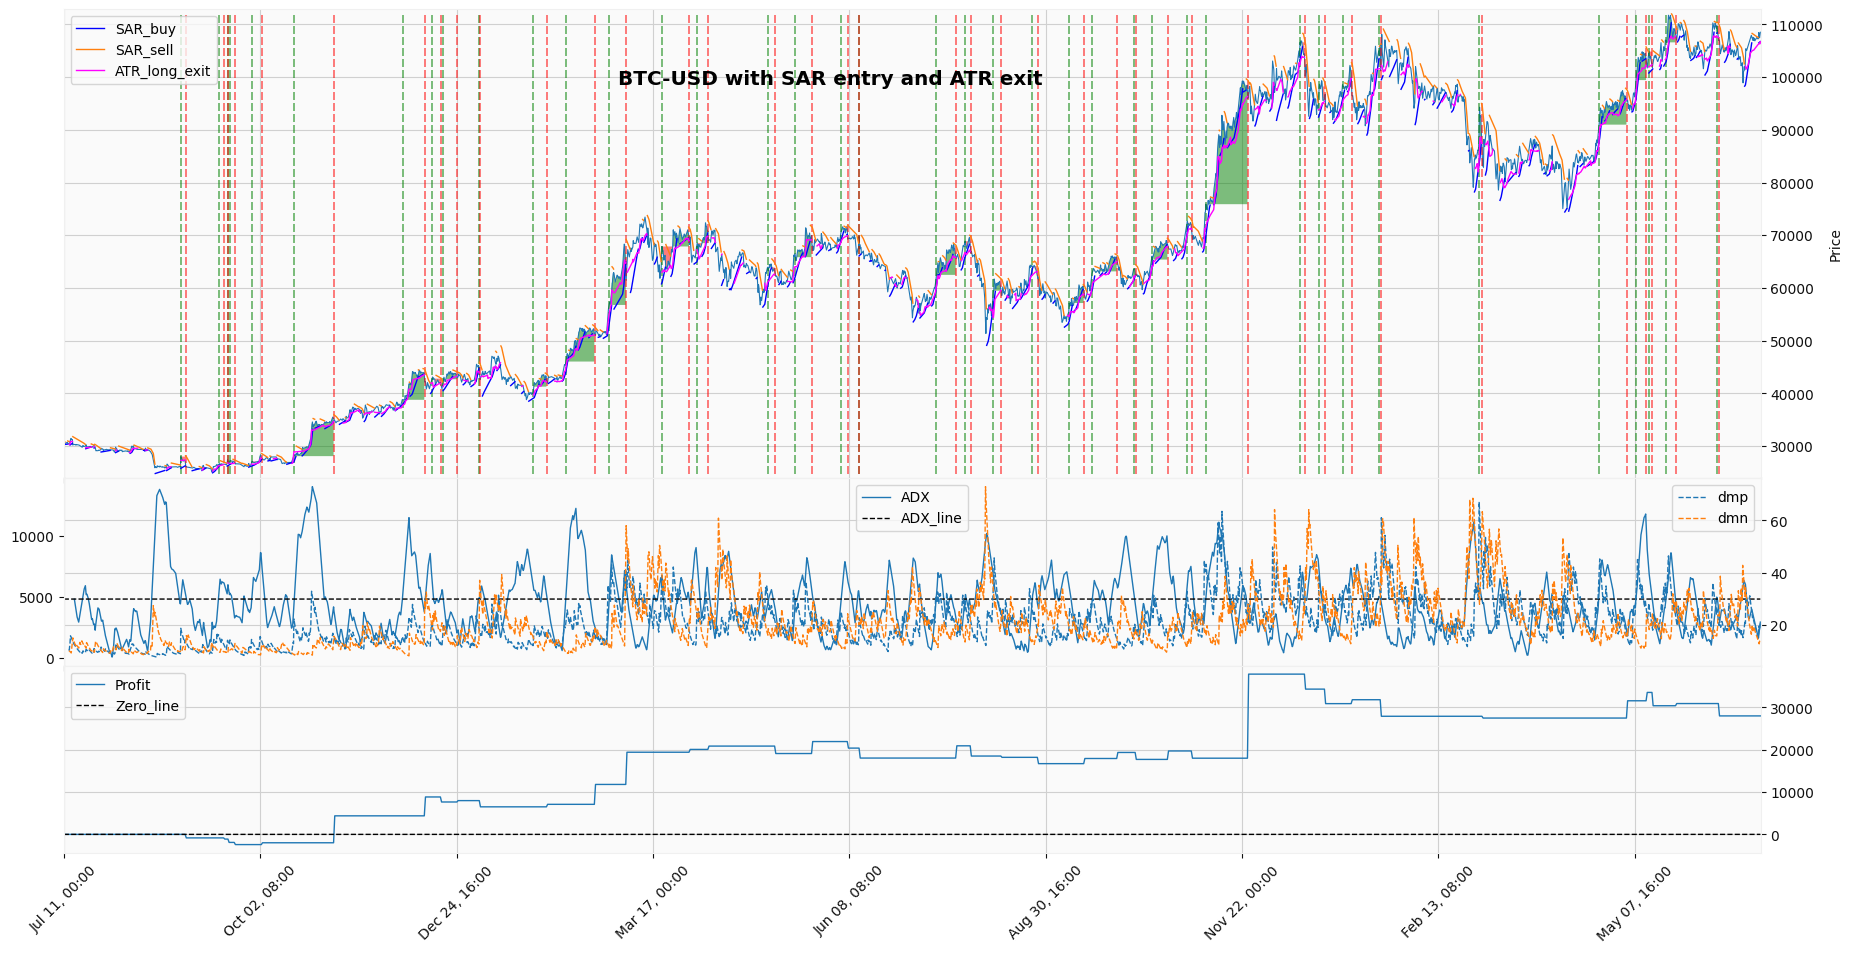

In [183]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(psar.iloc[:, 0], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(psar.iloc[:, 1], type='line', width=1.0, label='SAR_sell'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),
    # mpf.make_addplot(signals['ce_sh'], type='line', width=1.0, label='ATR_short_exit',
    #                  secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', width=1.0, label='ADX', panel=1),
    mpf.make_addplot(signals['adx_dmp'], type='line', linestyle='--', width=1.0, label='dmp', panel=1),
    mpf.make_addplot(signals['adx_dmn'], type='line', linestyle='--', width=1.0, label='dmn', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),
    mpf.make_addplot(profit_cum, type='line', width=1.0, label='Profit', panel=2),
    mpf.make_addplot(zero_line, type='line', color="black", linestyle='--', width=1.0, label='Zero_line', panel=2,
                     secondary_y=False),
    # mpf.make_addplot(profit, type='scatter', panel=3),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=False,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,
)


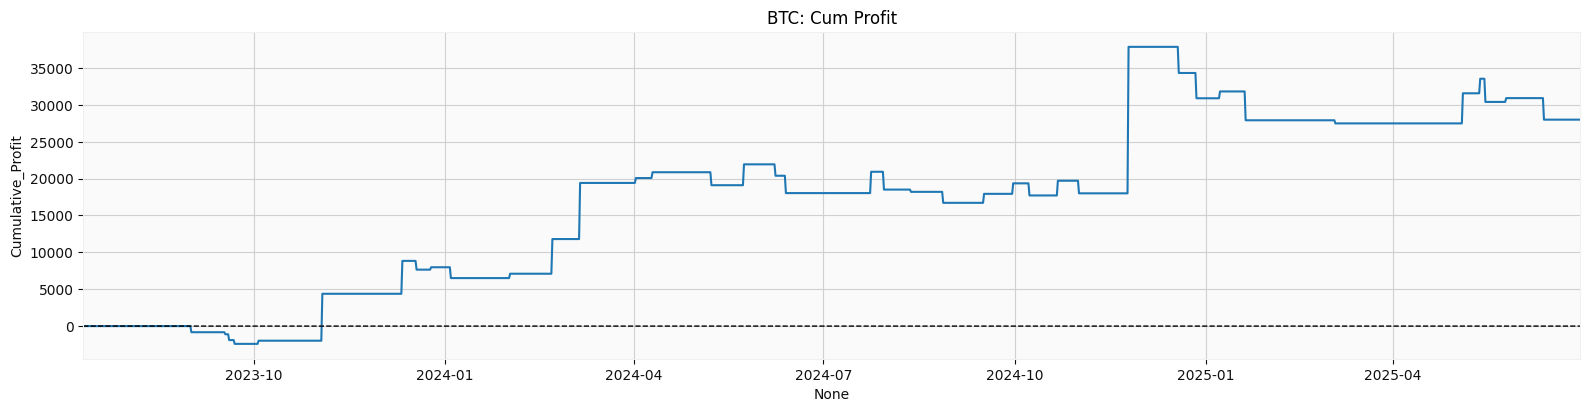

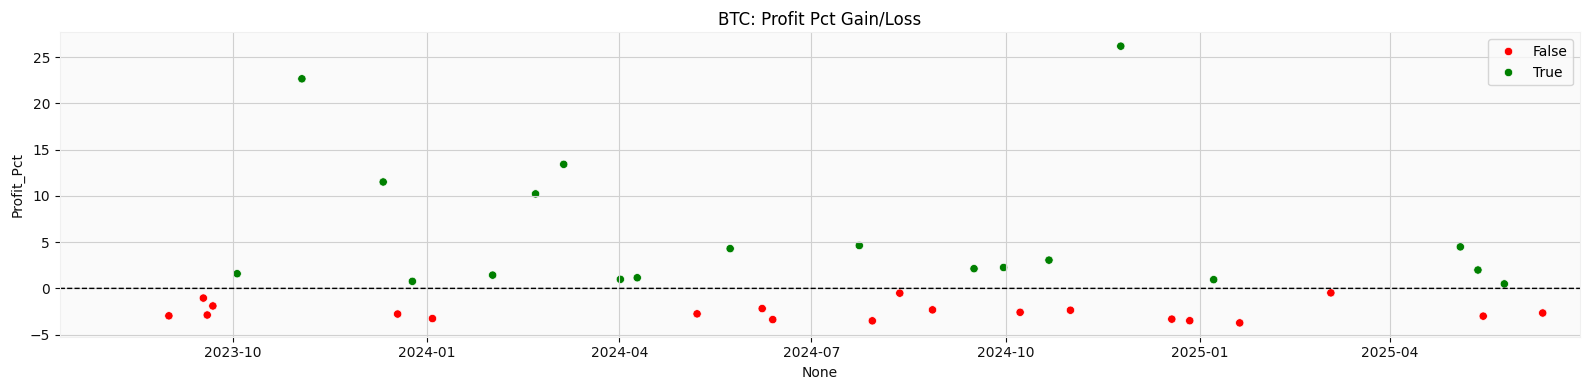

<Figure size 1600x400 with 0 Axes>

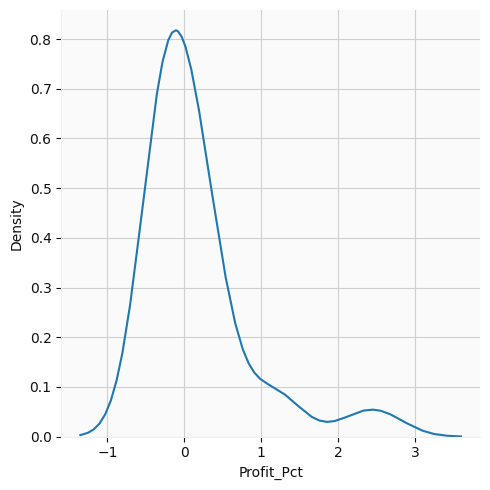

In [184]:
fig = plt.figure(figsize=(16, 4))  # wider figure
ax = plt.gca()

sns.lineplot(data=profit_df, x=profit_df.index, y=profit_df['Cumulative_Profit'])
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0)
plt.tight_layout()
plt.title(f"{symbols[0]}: Cum Profit")
ax.set_xlim(start, end)
plt.show()

fig2 = plt.figure(figsize=(16, 4))  # wider figure
ax2 = plt.gca()

sns.scatterplot(data=profit_df, x=profit_df.index, y=profit_df['Profit_Pct'] * 100, hue=profit_df['Profit_Pct'] > 0,
                palette={True: 'green', False: 'red'})
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0)
plt.title(f"{symbols[0]}: Profit Pct Gain/Loss")
plt.tight_layout()
ax2.set_xlim(start, end)
plt.show()

fig3 = plt.figure(figsize=(16, 4))  # wider figure
sns.displot(profit_df, x=profit_df['Profit_Pct'] * 10, kind="kde")
plt.tight_layout()
plt.show()